# 📊 Exploratory Data Analysis (EDA) & Day-Based Dataset Splitting

This notebook performs exploratory data profiling, feature distribution analysis, statistical boundary verification, correlation analysis, and **day-based dataset splitting** on the **Indoor Air Quality (IAQ) Classification Dataset** (`iaq_classification.csv`).

> **MLOps Best Practice:** All statistical profiling, EDA visualizations, and Pandera `pa.Field` boundary recommendations are computed **strictly on the Training Set (`train_df`)** to prevent data leakage from validation, test, and production drift streams.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic plot style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load raw dataset
raw_path = "../data/raw/iaq_classification.csv"
df = pd.read_csv(raw_path)
print(f"Raw Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Raw Dataset Shape: 139,074 rows x 12 columns


,Timestamp,Temperature (C),Humidity (%),Pressure (hPa),Gas Resistance (Ohms),PM2.5,TVOC (ppb),eCO2 (ppm),VOC Index,MQ135 Value,Voltage,PPM
0,2026-06-29 15:32:49,25.120430,39.847935,897.466577,1063067.0,6.0,766,408,471,183,0.590323,502.386553
1,2026-06-29 15:32:54,25.120234,39.859463,897.461183,1068057.0,5.0,760,424,471,186,0.600000,503.747368
2,2026-06-29 15:32:59,25.119453,39.865154,897.454926,1065556.0,5.0,763,414,471,186,0.600000,505.108183
3,2026-06-29 15:33:04,25.119258,39.859358,897.456340,1063067.0,5.0,781,422,471,186,0.600000,505.108183
4,2026-06-29 15:33:09,25.119258,39.870908,897.435914,1065556.0,5.0,778,421,471,186,0.600000,505.108183


--- 
## 1. Day-Based Dataset Splitting (Train, Val, Test, Data Drift Stream)

The dataset spans 9 calendar days (`2026-06-29` to `2026-07-07`). We split the data chronologically by calendar days:
- **Train Set (Days 1–5):** `2026-06-29` to `2026-07-03` (~54%)
- **Validation Set (Day 6):** `2026-07-04` (~12%)
- **Test Set (Day 7):** `2026-07-05` (~12%)
- **Production Drift Stream (Days 8–9):** `2026-07-06` to `2026-07-07` (~21%)

=== Day-Based Split Breakdown ===
  - Train Set (Days 1-5):         75,206 rows (54.1%)
  - Validation Set (Day 6):       17,279 rows (12.4%)
  - Test Set (Day 7):             17,280 rows (12.4%)
  - Production Drift (Days 8-9):  29,309 rows (21.1%)


/tmp/ipykernel_145416/1531433006.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Split", y="Rows", data=split_summary, palette="magma")


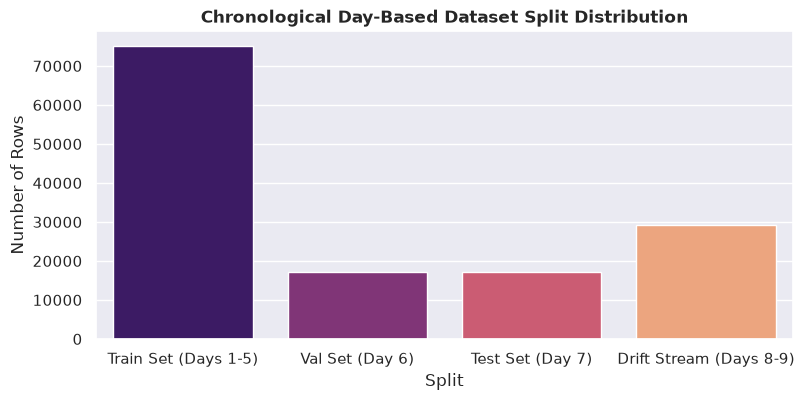

In [2]:
# Convert Timestamp to datetime and create date strings
df["dt"] = pd.to_datetime(df["Timestamp"])
df["date_str"] = df["dt"].dt.strftime("%Y-%m-%d")

train_days = ["2026-06-29", "2026-06-30", "2026-07-01", "2026-07-02", "2026-07-03"]
val_days = ["2026-07-04"]
test_days = ["2026-07-05"]
drift_days = ["2026-07-06", "2026-07-07"]

train_df = df[df["date_str"].isin(train_days)].drop(columns=["dt", "date_str"])
val_df = df[df["date_str"].isin(val_days)].drop(columns=["dt", "date_str"])
test_df = df[df["date_str"].isin(test_days)].drop(columns=["dt", "date_str"])
drift_df = df[df["date_str"].isin(drift_days)].drop(columns=["dt", "date_str"])

print("=== Day-Based Split Breakdown ===")
print(f"  - Train Set (Days 1-5):         {len(train_df):,} rows ({len(train_df)/len(df)*100:.1f}%)")
print(f"  - Validation Set (Day 6):       {len(val_df):,} rows ({len(val_df)/len(df)*100:.1f}%)")
print(f"  - Test Set (Day 7):             {len(test_df):,} rows ({len(test_df)/len(df)*100:.1f}%)")
print(f"  - Production Drift (Days 8-9):  {len(drift_df):,} rows ({len(drift_df)/len(df)*100:.1f}%)")

# Visualize Chronological Split Timeline
split_summary = pd.DataFrame({
    "Split": ["Train Set (Days 1-5)", "Val Set (Day 6)", "Test Set (Day 7)", "Drift Stream (Days 8-9)"],
    "Rows": [len(train_df), len(val_df), len(test_df), len(drift_df)]
})

plt.figure(figsize=(9, 4))
sns.barplot(x="Split", y="Rows", data=split_summary, palette="magma")
plt.title("Chronological Day-Based Dataset Split Distribution", fontsize=12, fontweight="bold")
plt.ylabel("Number of Rows")
plt.show()

--- 
## 2. Training Data Quality & Missing Value Audit (Computed on `train_df`)

In [3]:
# Audit missing values strictly on the Training Set
null_summary = pd.DataFrame({
    "Data Type": train_df.dtypes,
    "Null Count": train_df.isna().sum(),
    "Null %": (train_df.isna().sum() / len(train_df)) * 100
})
null_summary

,Data Type,Null Count,Null %
Timestamp,object,0,0.000000
Temperature (C),float64,0,0.000000
Humidity (%),float64,0,0.000000
Pressure (hPa),float64,0,0.000000
Gas Resistance (Ohms),float64,0,0.000000
PM2.5,float64,75,0.099726
TVOC (ppb),int64,0,0.000000
eCO2 (ppm),int64,0,0.000000
VOC Index,int64,0,0.000000
MQ135 Value,int64,0,0.000000


--- 
## 3. Training Set Numerical Boundaries (Computed on `train_df`)

In [4]:
# Compute percentiles strictly on train_df for Pandera pa.Field boundary selection
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
stats_list = []

for col in numeric_cols:
    series = train_df[col].dropna()
    stats_list.append({
        "Column": col,
        "Min": series.min(),
        "P1 (1%)": series.quantile(0.01),
        "Mean": series.mean(),
        "Median": series.median(),
        "P99 (99%)": series.quantile(0.99),
        "Max": series.max(),
        "Std": series.std()
    })

stats_df = pd.DataFrame(stats_list)
stats_df

,Column,Min,P1 (1%),Mean,Median,P99 (99%),Max,Std
0,Temperature (C),2.366984e+01,2.369523e+01,2.434520e+01,2.424328e+01,2.526477e+01,2.538762e+01,0.462330
1,Humidity (%),3.385386e+01,3.410756e+01,4.551829e+01,4.699805e+01,5.249745e+01,5.282183e+01,5.260069
2,Pressure (hPa),8.963784e+02,8.964662e+02,8.997943e+02,8.999072e+02,9.031223e+02,9.032337e+02,1.693286
3,Gas Resistance (Ohms),1.060590e+06,1.255671e+06,4.168178e+06,4.219417e+06,6.176814e+06,6.334428e+06,948381.065247
4,PM2.5,1.000000e+00,2.000000e+00,5.346994e+00,5.000000e+00,2.100000e+01,4.050000e+02,4.346027
5,TVOC (ppb),0.000000e+00,0.000000e+00,4.271948e+02,1.880000e+02,2.390000e+03,6.000000e+04,1631.702272
6,eCO2 (ppm),4.000000e+02,4.000000e+02,5.207829e+02,5.090000e+02,7.360000e+02,5.733000e+04,622.792054
7,VOC Index,4.600000e+01,5.000000e+01,2.282082e+02,1.510000e+02,4.990000e+02,5.000000e+02,161.844639
8,MQ135 Value,1.410000e+02,1.490000e+02,1.702854e+02,1.730000e+02,1.870000e+02,2.000000e+02,10.983118
9,Voltage,4.548387e-01,4.806452e-01,5.493078e-01,5.580645e-01,6.032258e-01,6.451613e-01,0.035429


--- 
## 4. Recommended Pandera pa.Field Schema Generator (From `train_df`)

In [5]:
# Print empirical pa.Field boundaries computed strictly from train_df
print("=== RECOMMENDED PANDERA pa.Field BOUNDARIES (FROM TRAIN SET) ===")
for col in numeric_cols:
    series = train_df[col].dropna()
    min_val = float(series.min())
    max_val = float(series.max())
    is_null = train_df[col].isna().sum() > 0
    print(f"  {col:25s} -> pa.Field(ge={min_val:.2f}, le={max_val:.2f}, nullable={is_null})")

=== RECOMMENDED PANDERA pa.Field BOUNDARIES (FROM TRAIN SET) ===
  Temperature (C)           -> pa.Field(ge=23.67, le=25.39, nullable=False)
  Humidity (%)              -> pa.Field(ge=33.85, le=52.82, nullable=False)
  Pressure (hPa)            -> pa.Field(ge=896.38, le=903.23, nullable=False)
  Gas Resistance (Ohms)     -> pa.Field(ge=1060590.00, le=6334428.00, nullable=False)
  PM2.5                     -> pa.Field(ge=1.00, le=405.00, nullable=True)
  TVOC (ppb)                -> pa.Field(ge=0.00, le=60000.00, nullable=False)
  eCO2 (ppm)                -> pa.Field(ge=400.00, le=57330.00, nullable=False)
  VOC Index                 -> pa.Field(ge=46.00, le=500.00, nullable=False)
  MQ135 Value               -> pa.Field(ge=141.00, le=200.00, nullable=False)
  Voltage                   -> pa.Field(ge=0.45, le=0.65, nullable=False)
  PPM                       -> pa.Field(ge=225.88, le=627.47, nullable=False)


--- 
## 5. Feature Distribution Plots (Computed on `train_df`)

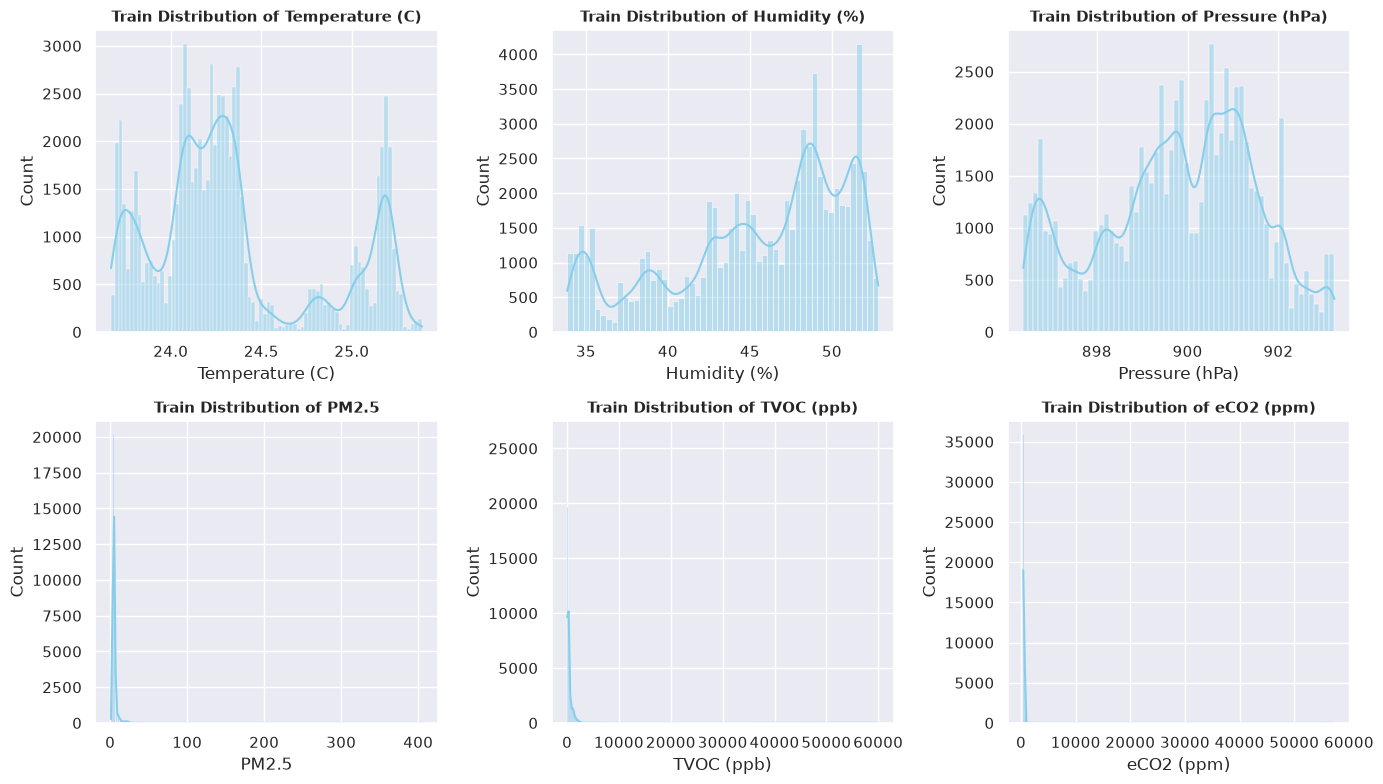

In [6]:
# Plot histograms strictly for train_df features
plt.figure(figsize=(14, 8))
features_to_plot = ["Temperature (C)", "Humidity (%)", "Pressure (hPa)", "PM2.5", "TVOC (ppb)", "eCO2 (ppm)"]

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_df[col].dropna(), kde=True, color="skyblue")
    plt.title(f"Train Distribution of {col}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

--- 
## 6. Feature Correlation Heatmap (Computed on `train_df`)

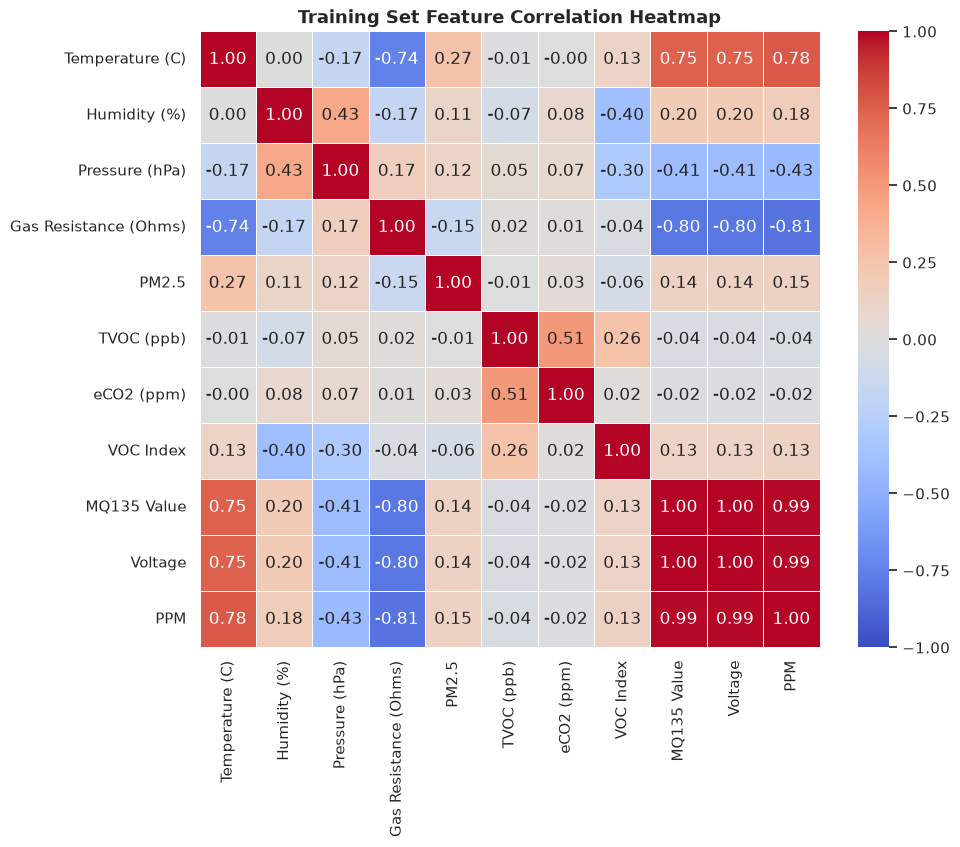

In [7]:
# Calculate Pearson correlation heatmap strictly on train_df
plt.figure(figsize=(10, 8))
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Training Set Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.show()

--- 
## 7. Target Risk Class Derivation & Distribution (Computed on `train_df`)

Training Set Target Class Distribution (0: Good, 1: Moderate, 2: High Risk):
IAQ_Class
0    51288
1    15567
2     8351
Name: count, dtype: int64


/tmp/ipykernel_145416/3535800921.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="IAQ_Class", data=train_df, palette="viridis")


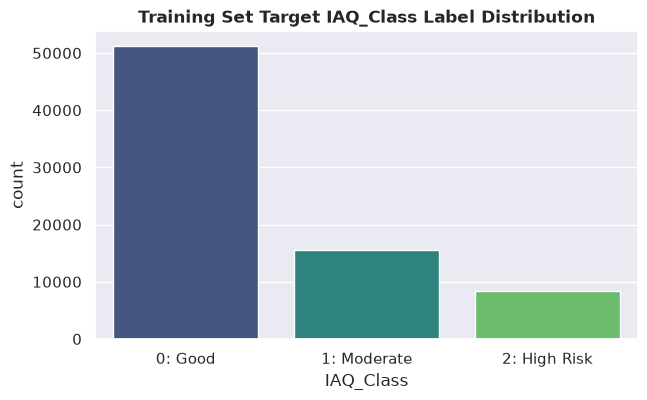

In [8]:
# Derive standard WHO/EPA indoor air quality risk class on train_df
def derive_iaq_class(row):
    pm25 = row["PM2.5"]
    tvoc = row["TVOC (ppb)"]
    if pm25 > 35.0 or tvoc > 1000.0:
        return 2  # High Risk / Unhealthy
    elif pm25 > 12.0 or tvoc > 300.0:
        return 1  # Moderate Risk
    else:
        return 0  # Good / Low Risk

train_df["IAQ_Class"] = train_df.apply(derive_iaq_class, axis=1)

class_counts = train_df["IAQ_Class"].value_counts().sort_index()
print("Training Set Target Class Distribution (0: Good, 1: Moderate, 2: High Risk):")
print(class_counts)

plt.figure(figsize=(7, 4))
sns.countplot(x="IAQ_Class", data=train_df, palette="viridis")
plt.xticks(ticks=[0, 1, 2], labels=["0: Good", "1: Moderate", "2: High Risk"])
plt.title("Training Set Target IAQ_Class Label Distribution", fontsize=12, fontweight="bold")
plt.show()